In [35]:
# Importing data
data <- read.csv('Fuel_Consumption_2000-2022.csv')

# Filtering columns
data <- data[, c("ENGINE.SIZE", "CYLINDERS", "FUEL.CONSUMPTION")]

# Checking for null values
colSums(is.na(data))

ENGINE.SIZE        CYLINDERS FUEL.CONSUMPTION 
               0                0                0

In [36]:
# Exploring data
summary(data)

  ENGINE.SIZE      CYLINDERS      FUEL.CONSUMPTION
 Min.   :0.800   Min.   : 2.000   Min.   : 3.50   
 1st Qu.:2.300   1st Qu.: 4.000   1st Qu.:10.40   
 Median :3.000   Median : 6.000   Median :12.30   
 Mean   :3.357   Mean   : 5.854   Mean   :12.76   
 3rd Qu.:4.200   3rd Qu.: 8.000   3rd Qu.:14.72   
 Max.   :8.400   Max.   :16.000   Max.   :30.60   

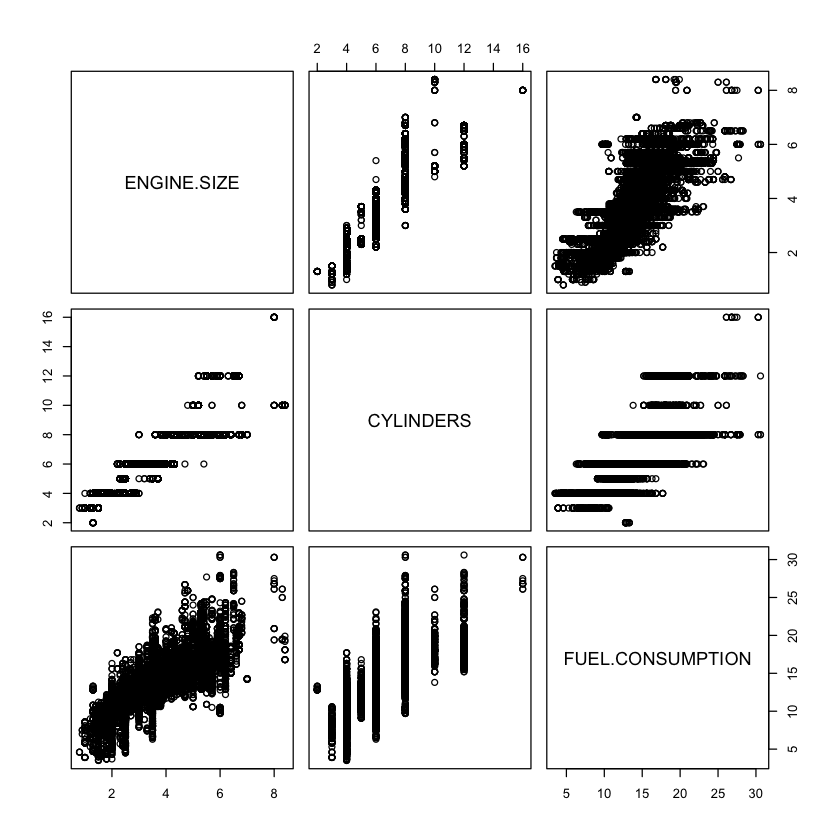

In [37]:
pairs(data[, c("ENGINE.SIZE", "CYLINDERS", "FUEL.CONSUMPTION")])

In [38]:
# Comparing models with CV

library(rsample)
library(purrr)
library(dplyr)

set.seed(552)

split <- initial_split(data, prop = 0.80)

train_data <- training(split)
test_data  <- testing(split)

folds <- vfold_cv(train_data, v = 10)

get_cv_rmse <- function(split, formula_str) {
    mod <- lm(as.formula(formula_str), data = analysis(split))
    holdout <- assessment(split)
    preds <- predict(mod, newdata = holdout)
    sqrt(mean((holdout$FUEL.CONSUMPTION - preds)^2))
}

models_to_test <- c(
    "Simple" = "FUEL.CONSUMPTION ~ ENGINE.SIZE + CYLINDERS",
    "Interaction" = "FUEL.CONSUMPTION ~ ENGINE.SIZE * CYLINDERS",
    "Poly-2" = "FUEL.CONSUMPTION ~ poly(ENGINE.SIZE, 2) + CYLINDERS",
    "Poly-2 + Interaction" = "FUEL.CONSUMPTION ~ poly(ENGINE.SIZE, 2) * CYLINDERS"
)

results <- map_dfr(names(models_to_test), function(model_name) {
    formula_str <- models_to_test[model_name]
    fold_rmses <- map_dbl(folds$splits, get_cv_rmse, formula_str = formula_str)
    data.frame(
        Model = model_name,
        Mean_RMSE = mean(fold_rmses)
    )
})

print(results)

                 Model Mean_RMSE
1               Simple  1.955187
2          Interaction  1.949988
3               Poly-2  1.941991
4 Poly-2 + Interaction  1.938344


In [39]:
# Building final model

model <- lm(FUEL.CONSUMPTION ~ poly(ENGINE.SIZE, 2) * CYLINDERS, data = train_data)
summary(model)


Call:
lm(formula = FUEL.CONSUMPTION ~ poly(ENGINE.SIZE, 2) * CYLINDERS, 
    data = train_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.6799 -1.1116 -0.1280  0.9321 13.2201 

Coefficients:
                                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)                      10.21704    0.13203  77.382  < 2e-16 ***
poly(ENGINE.SIZE, 2)1           178.57684   13.01201  13.724  < 2e-16 ***
poly(ENGINE.SIZE, 2)2           -69.40311    6.10774 -11.363  < 2e-16 ***
CYLINDERS                         0.39647    0.02521  15.727  < 2e-16 ***
poly(ENGINE.SIZE, 2)1:CYLINDERS  17.14523    2.36049   7.263 3.93e-13 ***
poly(ENGINE.SIZE, 2)2:CYLINDERS   1.15670    0.84476   1.369    0.171    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.938 on 18038 degrees of freedom
Multiple R-squared:  0.694,	Adjusted R-squared:  0.694 
F-statistic:  8183 on 5 and 18038 DF,  p-value: < 2.2e-16


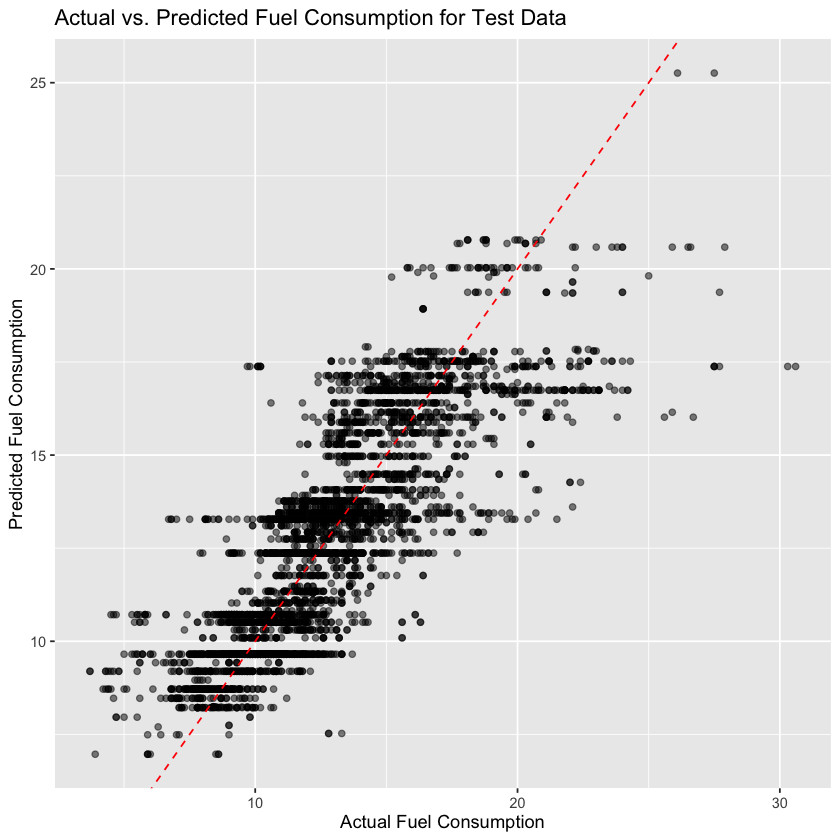

In [40]:
# Plotting model results for test data

library(ggplot2)

predictions <- predict(model, newdata = test_data)

results <- data.frame(actual = test_data$FUEL.CONSUMPTION, predicted = predictions)

ggplot(results, aes(x = actual, y = predicted)) +
  geom_point(alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, color = "red", linetype = "dashed") +
  labs(title = "Actual vs. Predicted Fuel Consumption for Test Data",
       x = "Actual Fuel Consumption",
       y = "Predicted Fuel Consumption")

In [41]:
# Getting Test RMSE

test_rmse <- sqrt(mean((test_data$FUEL.CONSUMPTION - predictions)^2))

test_rmse # model is typically off by this much in L/100 km

# Stratify on cylinders?

[1] 1.963227